# HMM et décodage de Viterbi — l'étiquetage morphosyntaxique probabiliste

**Navigation** : [<< Précédent — 04. Grammaires PCFG et parsing CYK](04_PCFG_CYK_Parsing.ipynb) | [Index de la série](README.md) | **05 (ce notebook)**

**Sommaire** : [1. Le corpus](#1-le-corpus--un-mini-pos-francais-synthetique) · [2. Le modèle](#2-le-hmm--deux-distributions-et-une-hypothese-markovienne) · [3. Forward](#3-forward--la-vraisemblance-pw-en-log-espace) · [4. Viterbi](#4-viterbi-et-backpointers--le-chemin-le-plus-probable) · [5. Le contexte renverse](#5-le-cas-non-degenere--la-ou-le-contexte-renverse-la-decision) · [6. Baseline](#6-la-baseline-independante-par-token--le-plancher-a-battre) · [7. Témoin hmmlearn](#7-temoin-bibliotheque-i--hmmlearn-les-memes-parametres-recharges) · [8. Témoin NLTK](#8-temoin-bibliotheque-ii--nltk-un-pipeline-complet-sans-lissage) · [9. Analyse d'erreurs](#9-analyse-derreurs--six-tokens-resistent) · [Exercices](#exercice-1--backward-et-decodage-marginal-mpm) · [Conclusion](#conclusion--la-sequence-comme-preuve-la-mesure-comme-juge)

Le [02_NGrammes_Modeles_De_Langue](02_NGrammes_Modeles_De_Langue.ipynb) a modélisé `P(phrase)` en comptant les **mots observés**. Ce notebook franchit l'étape historique suivante : et si ce qui intéresse — ici, la **catégorie grammaticale** de chaque mot — n'est **pas observé** ? Un modèle de Markov caché (HMM) suppose que la phrase est **générée** par une chaîne d'étiquettes invisibles : une chaîne de Markov d'états (les catégories) émet des symboles observés (les mots). Étiqueter, c'est alors **retrouver la chaîne d'états la plus probable** ayant pu produire la phrase — par programmation dynamique, avec l'algorithme de **Viterbi** et ses backpointers.

**Le fil conducteur** : le français regorge de mots ambigus — *la porte verte* (nom) contre *elle porte une robe* (verbe), et même *le matelot voile la voile* où les deux lectures cohabitent dans la même phrase. Un décideur token par token ne peut pas les départager ; une chaîne de Markov sur les étiquettes le peut, parce que `DET → NOM` et `PRON → VER` sont des transitions de probabilités très différentes. Ce notebook **mesure** ce renversement, token par token.

**Approche** : tout est construit from scratch sur CPU — estimation MLE des transitions et émissions, lissage add-1, forward en log-espace, Viterbi avec backpointers. Chaque algorithme est ensuite confronté à un **témoin bibliothèque réellement exécuté** : `hmmlearn` recharge **les mêmes paramètres** et doit reproduire forward et Viterbi à l'identique ; `nltk` entraîne son propre HMM supervisé **sans lissage** — et son effondrement mesuré sur les mots inconnus justifie le nôtre.

**Position dans la série** : le HMM est le modèle **génératif** de l'étiquetage séquentiel ; le [03_CRF_Etiquetage_Sequentiel](03_CRF_Etiquetage_Sequentiel.ipynb) en montrera le pendant **discriminatif** (CRF linéaire, Lafferty et al. 2001), qui apprend les mêmes transitions mais conditionnellement aux mots. Les deux notebooks partagent le même plan d'expérience : baseline token-wise, témoin bibliothèque, analyse d'erreurs.

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. **Formuler** l'étiquetage morphosyntaxique comme inférence dans un modèle de Markov caché : états, émissions, hypothèse markovienne ;
2. **Estimer** les paramètres d'un HMM par maximum de vraisemblance sur un corpus annoté, avec lissage add-1 et symbole d'inconnu ;
3. **Implémenter** l'algorithme forward en log-espace (vraisemblance `log P(W)`) et le décodage de Viterbi avec backpointers (chemin le plus probable) ;
4. **Mesurer** l'apport du contexte de séquence : là où le renversement de décision par rapport à un décideur token par token se produit, et ce qu'il corrige ;
5. **Confronter** l'implémentation à deux bibliothèques exécutées (`hmmlearn` en concordance exacte, `nltk` sans lissage en contre-exemple mesuré).

### Prérequis

- Python 3.10+, NumPy (déjà utilisés dans la série)
- Avoir parcouru le [02_NGrammes_Modeles_De_Langue](02_NGrammes_Modeles_De_Langue.ipynb) (MLE, lissage, perplexité)

### Durée estimée : 55 minutes

## 1. Le corpus — un mini-POS français synthétique

Le corpus embarqué ci-dessous est **synthétique** : il a été **rédigé à la main pour ce notebook** (dépôt CoursIA, issue #17695), dans le prolongement du registre du [03_CRF_Etiquetage_Sequentiel](03_CRF_Etiquetage_Sequentiel.ipynb).

> **Provenance et statut** — Corpus **synthétique, écrit pour ce notebook** ; il **n'est pas** un corpus de référence (ni Universal Dependencies, ni French Treebank) et ses statistiques n'ont valeur que pédagogique. Il est conçu pour exposer de façon auditable trois phénomènes : (a) des mots ambigus **NOM/VER** (*porte*, *voile*, *coupe*, *garde*, *avance*), (b) des clitiques **DET/PRON** (*le*, *la*, *les*), (c) une phrase-test où **les deux lectures d'un même mot cohabitent** (*le matelot voile la voile*). Licence : celle du dépôt.

Le jeu d'étiquettes compte 8 catégories : `DET`, `NOM`, `VER`, `ADJ`, `PREP`, `PRON`, `ADV`, `PUNCT` — un POS simplifié, volontairement resserré pour que le treillis de la section 4 reste lisible cellule par cellule.

In [1]:
import sys
from collections import Counter
import numpy as np
import nltk
import hmmlearn

print(f"Python {sys.version.split()[0]} | numpy {np.__version__} | nltk {nltk.__version__} | hmmlearn {hmmlearn.__version__}")
print("Imports OK : numpy (algebre), nltk (temoin II), hmmlearn (temoin I)")

Python 3.13.14 | numpy 2.4.4 | nltk 3.10.3 | hmmlearn 0.3.3
Imports OK : numpy (algebre), nltk (temoin II), hmmlearn (temoin I)


### Lecture — l'environnement réellement exécuté

La cellule ci-dessus confirme les **versions effectives** de l'environnement d'exécution — elles sont la source de vérité pour ce notebook (aucune version n'est épinglée à la main dans la prose). Tout ce qui suit tourne sur CPU, sans hasard : **aucune graine n'est nécessaire**, l'estimation MLE et les deux algorithmes de programmation dynamique sont déterministes.

In [2]:
# Corpus POS francais SYNTHETIQUE (provenance : redige pour CoursIA #17695, cf. section 1).
# Chaque phrase : liste de (token, etiquette). 8 categories.
CORPUS = [
    # --- contexte NOM pour les mots ambigus porte / voile / coupe / garde / avance ---
    [("la", "DET"), ("porte", "NOM"), ("verte", "ADJ"), ("est", "VER"), ("fermée", "ADJ"), (".", "PUNCT")],
    [("une", "DET"), ("voile", "NOM"), ("blanche", "ADJ"), ("glisse", "VER"), ("sur", "PREP"), ("la", "DET"), ("mer", "NOM"), (".", "PUNCT")],
    [("la", "DET"), ("coupe", "NOM"), ("dorée", "ADJ"), ("brille", "VER"), ("sur", "PREP"), ("la", "DET"), ("table", "NOM"), (".", "PUNCT")],
    [("la", "DET"), ("garde", "NOM"), ("royale", "ADJ"), ("dort", "VER"), ("encore", "ADV"), (".", "PUNCT")],
    [("une", "DET"), ("avance", "NOM"), ("sérieuse", "ADJ"), ("surprend", "VER"), ("la", "DET"), ("banque", "NOM"), (".", "PUNCT")],
    [("le", "DET"), ("voile", "NOM"), ("noir", "ADJ"), ("recouvre", "VER"), ("la", "DET"), ("fenêtre", "NOM"), (".", "PUNCT")],
    [("la", "DET"), ("porte", "NOM"), ("grince", "VER"), ("dans", "PREP"), ("la", "DET"), ("maison", "NOM"), (".", "PUNCT")],
    [("leur", "DET"), ("garde", "NOM"), ("veille", "VER"), ("toute", "DET"), ("la", "DET"), ("nuit", "NOM"), (".", "PUNCT")],
    # --- contexte VER (3e personne) ---
    [("il", "PRON"), ("porte", "VER"), ("un", "DET"), ("manteau", "NOM"), ("gris", "ADJ"), (".", "PUNCT")],
    [("elle", "PRON"), ("voile", "VER"), ("la", "DET"), ("fenêtre", "NOM"), ("sale", "ADJ"), (".", "PUNCT")],
    [("il", "PRON"), ("coupe", "VER"), ("la", "DET"), ("pomme", "NOM"), ("rouge", "ADJ"), (".", "PUNCT")],
    [("il", "PRON"), ("garde", "VER"), ("la", "DET"), ("clé", "NOM"), ("précieuse", "ADJ"), (".", "PUNCT")],
    [("elle", "PRON"), ("avance", "VER"), ("doucement", "ADV"), ("dans", "PREP"), ("le", "DET"), ("brouillard", "NOM"), (".", "PUNCT")],
    [("la", "DET"), ("femme", "NOM"), ("porte", "VER"), ("un", "DET"), ("chapeau", "NOM"), (".", "PUNCT")],
    [("le", "DET"), ("vent", "NOM"), ("voile", "VER"), ("les", "DET"), ("toits", "NOM"), (".", "PUNCT")],
    [("le", "DET"), ("cuisinier", "NOM"), ("coupe", "VER"), ("le", "DET"), ("pain", "NOM"), (".", "PUNCT")],
    [("la", "DET"), ("nourrice", "NOM"), ("garde", "VER"), ("les", "DET"), ("enfants", "NOM"), (".", "PUNCT")],
    [("la", "DET"), ("procession", "NOM"), ("avance", "VER"), ("lentement", "ADV"), (".", "PUNCT")],
    # --- clitiques : le / la / les DET vs PRON (seconde couche d'ambiguite) ---
    [("il", "PRON"), ("le", "PRON"), ("garde", "VER"), ("précieusement", "ADV"), (".", "PUNCT")],
    [("elle", "PRON"), ("la", "PRON"), ("porte", "VER"), ("toujours", "ADV"), (".", "PUNCT")],
    [("on", "PRON"), ("les", "PRON"), ("coupe", "VER"), ("chaque", "DET"), ("matin", "NOM"), (".", "PUNCT")],
    [("il", "PRON"), ("la", "PRON"), ("voile", "VER"), ("encore", "ADV"), (".", "PUNCT")],
    # --- phrases non ambigues : la statistique de fond ---
    [("le", "DET"), ("chat", "NOM"), ("dort", "VER"), (".", "PUNCT")],
    [("la", "DET"), ("souris", "NOM"), ("mange", "VER"), ("sans", "PREP"), ("bruit", "NOM"), (".", "PUNCT")],
    [("un", "DET"), ("homme", "NOM"), ("lit", "VER"), ("le", "DET"), ("journal", "NOM"), (".", "PUNCT")],
    [("elle", "PRON"), ("chante", "VER"), ("dans", "PREP"), ("la", "DET"), ("cuisine", "NOM"), (".", "PUNCT")],
    [("le", "DET"), ("facteur", "NOM"), ("ouvre", "VER"), ("la", "DET"), ("boîte", "NOM"), ("bleue", "ADJ"), (".", "PUNCT")],
    [("ils", "PRON"), ("observent", "VER"), ("la", "DET"), ("scène", "NOM"), (".", "PUNCT")],
    [("la", "DET"), ("lumière", "NOM"), ("éclaire", "VER"), ("le", "DET"), ("jardin", "NOM"), (".", "PUNCT")],
    [("un", "DET"), ("enfant", "NOM"), ("dessine", "VER"), ("sur", "PREP"), ("une", "DET"), ("page", "NOM"), ("blanche", "ADJ"), (".", "PUNCT")],
    [("elle", "PRON"), ("ferme", "VER"), ("la", "DET"), ("fenêtre", "NOM"), (".", "PUNCT")],
    [("le", "DET"), ("journal", "NOM"), ("annonce", "VER"), ("une", "DET"), ("réponse", "NOM"), ("claire", "ADJ"), (".", "PUNCT")],
    # --- phrases TEST : ambigus dont certains en contexte minoritaire, un double sens, des inconnus ---
    [("la", "DET"), ("voile", "NOM"), ("rouge", "ADJ"), ("tourne", "VER"), (".", "PUNCT")],
    [("elle", "PRON"), ("porte", "VER"), ("une", "DET"), ("robe", "NOM"), ("bleue", "ADJ"), (".", "PUNCT")],
    [("il", "PRON"), ("voile", "VER"), ("la", "DET"), ("vérité", "NOM"), (".", "PUNCT")],
    [("le", "DET"), ("garde", "NOM"), ("ferme", "VER"), ("la", "DET"), ("grille", "NOM"), (".", "PUNCT")],
    [("elle", "PRON"), ("coupe", "VER"), ("le", "DET"), ("gazon", "NOM"), (".", "PUNCT")],
    [("la", "DET"), ("coupe", "NOM"), ("brille", "VER"), (".", "PUNCT")],
    [("il", "PRON"), ("la", "PRON"), ("garde", "VER"), (".", "PUNCT")],
    [("une", "DET"), ("avance", "NOM"), ("rapide", "ADJ"), ("surprend", "VER"), (".", "PUNCT")],
    [("le", "DET"), ("matelot", "NOM"), ("voile", "VER"), ("la", "DET"), ("voile", "NOM"), (".", "PUNCT")],
    [("le", "DET"), ("concierge", "NOM"), ("ouvre", "VER"), ("la", "DET"), ("porte", "NOM"), ("verte", "ADJ"), (".", "PUNCT")],
]

n_tok = sum(len(s) for s in CORPUS)
vocab_corpus = sorted({w for s in CORPUS for w, _ in s})
print(f"Corpus : {len(CORPUS)} phrases, {n_tok} tokens, {len(vocab_corpus)} types, {len(set(t for s in CORPUS for _, t in s))} etiquettes")

Corpus : 42 phrases, 250 tokens, 98 types, 8 etiquettes


### Lecture — le corpus synthétique en chiffres

**42 phrases, 250 tokens, 98 types, 8 étiquettes** (sortie ci-dessus) : c'est un corpus miniature délibéré — assez petit pour auditer chaque phrase, assez structuré pour que les comptages MLE portent. Les phrases sont organisées en quatre blocs visibles dans le code : contextes **NOM** des mots ambigus, contextes **VER**, phrases à **clitiques** (*il le garde* : `le` est alors pronom), et phrases de fond non ambiguës. Les dix dernières phrases constituent le **test** — choisies pour placer certains mots ambigus dans leur contexte **minoritaire** du train (*la voile*, *le garde*, *une avance*, *la coupe*, *la porte*, et *la* pronom : 7 des 22 occurrences d'ambigus y sont minoritaires, les autres restent en contexte majoritaire), et pour contenir des mots inconnus (*robe*, *matelot*, *vérité*…).

TRAIN : 32 phrases / 197 tokens   TEST : 10 phrases / 53 tokens
Mots ambigus (8) : avance, coupe, garde, la, le, les, porte, voile
Mots du TEST inconnus du TRAIN (8) : concierge, gazon, grille, matelot, rapide, robe, tourne, vérité
Distribution TRAIN : {'DET': 45, 'NOM': 45, 'ADJ': 14, 'VER': 32, 'PUNCT': 32, 'PREP': 7, 'ADV': 6, 'PRON': 16}


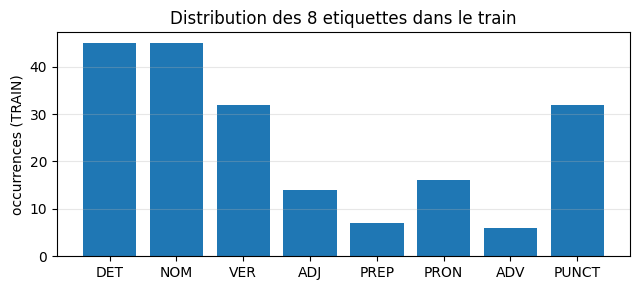

In [3]:
# Split deterministe, une fois pour toutes : les 10 dernieres phrases = test.
TRAIN = CORPUS[:-10]
TEST = CORPUS[-10:]

TAGS = ["DET", "NOM", "VER", "ADJ", "PREP", "PRON", "ADV", "PUNCT"]
tag_idx = {t: i for i, t in enumerate(TAGS)}

# Mots ambigus : vus avec plus d'une etiquette dans le corpus complet.
sens = {}
for s in CORPUS:
    for w, t in s:
        sens.setdefault(w, set()).add(t)
mots_ambigus = sorted(w for w, ts in sens.items() if len(ts) > 1)

train_words = {w for s in TRAIN for w, _ in s}
inconnus_test = sorted({w for s in TEST for w, _ in s if w not in train_words})

n_tr = sum(len(s) for s in TRAIN); n_te = sum(len(s) for s in TEST)
print(f"TRAIN : {len(TRAIN)} phrases / {n_tr} tokens   TEST : {len(TEST)} phrases / {n_te} tokens")
print(f"Mots ambigus ({len(mots_ambigus)}) : {', '.join(mots_ambigus)}")
print(f"Mots du TEST inconnus du TRAIN ({len(inconnus_test)}) : {', '.join(inconnus_test)}")

dist = Counter(t for s in TRAIN for _, t in s)
print("Distribution TRAIN :", dict(dist))

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 3.0))
counts = [dist[t] for t in TAGS]
ax.bar(TAGS, counts, color="#1f77b4")
ax.set_ylabel("occurrences (TRAIN)")
ax.set_title("Distribution des 8 etiquettes dans le train")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### Lecture — ambiguïté et inconnus, les deux ennemis mesurés

La sortie ci-dessus liste **8 mots ambigus** : les cinq NOM/VER (*avance, coupe, garde, porte, voile*) et les trois clitiques DET/PRON (*la, le, les*). Elle liste aussi **8 types inconnus** du train présents dans le test — c'est le second problème : un MLE brut donnerait `P(w|t) = 0` pour chacun, donc une vraisemblance nulle sur la moitié du test. Ces deux listes pilotent tout le notebook : l'ambiguïté justifie Viterbi (sections 4–5), les inconnus justifient le lissage (section 2) et expliquent l'effondrement du témoin NLTK (section 8). La distribution du train — `DET` et `NOM` largement en tête — est visible sur la figure : c'est un français de phrases simples, avec un verbe par phrase.

## 2. Le HMM — deux distributions et une hypothèse markovienne

Un HMM d'étiquetage suppose que la phrase annotée $(w_1, \dots, w_T, t_1, \dots, t_T)$ est générée ainsi :

$$P(T, W) \;=\; \pi(t_1) \cdot B_{t_1}(w_1) \cdot \prod_{i=2}^{T} A_{t_{i-1}, t_i} \cdot B_{t_i}(w_i)$$

où — avec $K = 8$ états et un vocabulaire $V$ :

- $\pi$ est la distribution des **étiquettes initiales** $P(t_1)$ ;
- $A \in \mathbb{R}^{K \times K}$ est la **matrice de transitions** $P(t_i \mid t_{i-1})$ — l'hypothèse markovienne : une étiquette ne dépend que de la **précédente** ;
- $B \in \mathbb{R}^{K \times V}$ est la matrice d'**émissions** $P(w_i \mid t_i)$ — chaque état tire son mot.

Sur un corpus annoté, l'estimation par maximum de vraisemblance est un simple **comptage** : chaque occurrence de bigramme d'étiquettes incrémente $A$, chaque paire (étiquette, mot) incrémente $B$. Le piège est elsewhere : les zéros. Une transition jamais vue, un mot jamais émis par une étiquette, un mot **inconnu** du train — chacun vaut $\log 0 = -\infty$ et tue la suite. Nous appliquons le lissage **add-1** (Laplace) des deux côtés, avec un symbole d'inconnu `<UNK>` ajouté au vocabulaire — exactement le remède du [02_NGrammes_Modeles_De_Langue](02_NGrammes_Modeles_De_Langue.ipynb), transposé aux étiquettes.

In [4]:
ALPHA_T, ALPHA_E = 1.0, 1.0      # lissage add-1 (Laplace) : transitions et emissions
UNK = "<UNK>"

def estimer_hmm(corpus, alpha_t=ALPHA_T, alpha_e=ALPHA_E):
    """MLE + lissage add-alpha -> pi, A, B (probabilites), et leurs logs."""
    A_cnt, B_cnt, PI_cnt = Counter(), Counter(), Counter()
    n_tag = Counter()
    for sent in corpus:
        prev = None
        for i, (w, t) in enumerate(sent):
            n_tag[t] += 1
            B_cnt[(t, w)] += 1
            if prev is None:
                PI_cnt[t] += 1
            else:
                A_cnt[(prev, t)] += 1
            prev = t
    vocab = sorted({w for s in corpus for w, _ in s}) + [UNK]
    w_idx = {w: i for i, w in enumerate(vocab)}
    K, V = len(TAGS), len(vocab)
    A = np.full((K, K), alpha_t);  B = np.full((K, V), alpha_e);  PI = np.full(K, alpha_t)
    for (a, b), c in A_cnt.items(): A[tag_idx[a], tag_idx[b]] += c
    for (t, w), c in B_cnt.items(): B[tag_idx[t], w_idx[w]] += c
    for t, c in PI_cnt.items(): PI[tag_idx[t]] += c
    A /= A.sum(axis=1, keepdims=True);  B /= B.sum(axis=1, keepdims=True);  PI /= PI.sum()
    return PI, A, B, vocab, w_idx, n_tag

PI, A, B, VOCAB, w_idx, n_tag = estimer_hmm(TRAIN)
logPI, logA, logB = np.log(PI), np.log(A), np.log(B)
UNK_I = w_idx[UNK]
K, V = len(TAGS), len(VOCAB)

def wi(w):
    """Index du mot, avec repli sur le symbole d'inconnu."""
    return w_idx.get(w, UNK_I)

print(f"Parametres estimes : pi ({K}), A ({K}x{K}), B ({K}x{V}, dont <UNK>)")
print(f"P(NOM | DET)   = {A[tag_idx['DET'], tag_idx['NOM']]:.3f}")
print(f"P(VER | PRON)  = {A[tag_idx['PRON'], tag_idx['VER']]:.3f}")
print(f"P(<UNK>| ADV)  = {B[tag_idx['ADV'], UNK_I]:.4f}  (l'ADV, etiquette la plus rare, capte les inconnus)")

Parametres estimes : pi (8), A (8x8), B (8x91, dont <UNK>)
P(NOM | DET)   = 0.849
P(VER | PRON)  = 0.542
P(<UNK>| ADV)  = 0.0103  (l'ADV, etiquette la plus rare, capte les inconnus)


### Lecture — trois tables, et un effet de bord du lissage

Les transitions racontent la grammaire du corpus : `P(NOM | DET)` et `P(VER | PRON)` (sortie ci-dessus) sont les deux colonnes qui feront tout le travail de la section 5 — un déterminant appelle un nom, un pronom appelle un verbe. L'effet de bord visible sur la troisième ligne est un **piège classique du add-1** : l'étiquette la plus rare (`ADV` ici) reçoit la probabilité d'inconnu **la plus élevée**, puisque le lissage répartit la masse $\alpha$ sur un dénominateur plus petit. Conséquence mesurée en section 9 : un mot inconnu **verbal** (*tourne*) sera d'abord attiré par `ADV` au niveau des émissions — c'est le contexte de transitions qui le tirera vers le bon état.

Emissions lissees des mots ambigus NOM/VER :
mot        P(w|NOM)   P(w|VER)   rapport VER/NOM
porte        0.0221     0.0325     1.47x
voile        0.0221     0.0325     1.47x
coupe        0.0147     0.0325     2.21x
garde        0.0221     0.0325     1.47x
avance       0.0147     0.0244     1.66x

Clitiques DET vs PRON :
le       P(w|DET)=0.0809   P(w|PRON)=0.0187
la       P(w|DET)=0.1691   P(w|PRON)=0.0280
les      P(w|DET)=0.0221   P(w|PRON)=0.0187


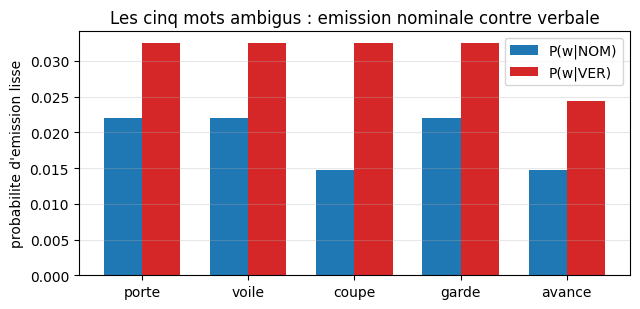

In [5]:
AMBIGUS_NV = ["porte", "voile", "coupe", "garde", "avance"]
print("Emissions lissees des mots ambigus NOM/VER :")
print(f"{'mot':8s} {'P(w|NOM)':>10s} {'P(w|VER)':>10s}   rapport VER/NOM")
for w in AMBIGUS_NV:
    pn, pv = B[tag_idx["NOM"], wi(w)], B[tag_idx["VER"], wi(w)]
    print(f"{w:8s} {pn:10.4f} {pv:10.4f}   {pv/pn:6.2f}x")

print()
print("Clitiques DET vs PRON :")
for w in ["le", "la", "les"]:
    pd, pp = B[tag_idx["DET"], wi(w)], B[tag_idx["PRON"], wi(w)]
    print(f"{w:8s} P(w|DET)={pd:.4f}   P(w|PRON)={pp:.4f}")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
x = np.arange(len(AMBIGUS_NV))
pn = [B[tag_idx["NOM"], wi(w)] for w in AMBIGUS_NV]
pv = [B[tag_idx["VER"], wi(w)] for w in AMBIGUS_NV]
ax.bar(x - 0.18, pn, width=0.36, label="P(w|NOM)", color="#1f77b4")
ax.bar(x + 0.18, pv, width=0.36, label="P(w|VER)", color="#d62728")
ax.set_xticks(x, AMBIGUS_NV)
ax.set_ylabel("probabilite d'emission lisse")
ax.set_title("Les cinq mots ambigus : emission nominale contre verbale")
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### Lecture — les émissions ordonnent, mais ne décident pas

Pour chacun des cinq mots, l'émission **verbale** domine la nominale dans le train (rapports supérieurs à 1 dans la sortie) : *porte* apparaît plus souvent comme verbe. Un décideur qui ne regarde que `P(w|t)` — ou de façon équivalente le tag majoritaire par mot — choisira donc **toujours VER**, et se trompera sur *la porte verte*. La figure montre l'écart : réel, mais **modeste** (l'émission nominale reste du même ordre de grandeur). C'est précisément cette marge étroite qui rend le renversement par contexte possible : une transition `DET → NOM` massive suffit à la faire basculer. Les clitiques sont dans le même cas, `P(la|DET)` dominant `P(la|PRON)` — la section 5 montrera le cas *il la garde*, où les deux ambiguïtés se superposent.

## 3. Forward — la vraisemblance P(W) en log-espace

Avant de décoder, mesurons : quelle probabilité le modèle accorde-t-il à une **phrase** ? L'algorithme forward calcule

$$\log P(W) \;=\; \log \sum_{t_1, \dots, t_T} P(T, W),$$

la somme sur **tous les chemins d'étiquettes** possibles — à distinguer soigneusement du **maximum** de Viterbi (section 4). La récurrence, en log-espace pour éviter l'underflow ($K^T$ chemins, chacun un produit de $2T$ probabilités) :

$$\alpha_1(k) = \log\pi_k + \log B_k(w_1), \qquad \alpha_i(k) = \log \sum_j e^{\,\alpha_{i-1}(j) + \log A_{jk}} + \log B_k(w_i),$$

réalisée avec `np.logaddexp` — le compagnon exact de la somme en log-espace. La table $\alpha$ cumule des **sommes partielles** : à ne pas confondre avec la table $\delta$ du **max** que Viterbi remplira sur le même treillis (section 4). C'est la même table triangulaire que la log-partition du CRF du [03_CRF_Etiquetage_Sequentiel](03_CRF_Etiquetage_Sequentiel.ipynb), et la même famille que la vraisemblance n-gramme du [02_NGrammes_Modeles_De_Langue](02_NGrammes_Modeles_De_Langue.ipynb) — mais marginalisée sur des états **cachés** au lieu d'être conditionnée aux mots observés.

In [6]:
def forward_log(words_seq):
    """log P(W) par l'algorithme forward, en log-espace (logaddexp)."""
    T = len(words_seq)
    alpha = np.full((T, K), -np.inf)
    alpha[0] = logPI + logB[:, wi(words_seq[0])]
    for t in range(1, T):
        for k in range(K):
            alpha[t, k] = np.logaddexp.reduce(alpha[t - 1] + logA[:, k]) + logB[k, wi(words_seq[t])]
    return np.logaddexp.reduce(alpha[-1])

print("log P(W) du modele sur chaque phrase du TEST (lisse, add-1) :")
for i, s in enumerate(TEST):
    print(f"  test[{i}] {' '.join(w for w, _ in s):40s} logP = {forward_log([w for w, _ in s]):8.3f}")

lp_v = forward_log([w for w, _ in TEST[8]])
print()
print(f"Phrase a double lecture  : log P(W) = {lp_v:.3f}  (somme sur les {K}^{len(TEST[8])} chemins d'etats)")

log P(W) du modele sur chaque phrase du TEST (lisse, add-1) :
  test[0] la voile rouge tourne .                  logP =  -18.490
  test[1] elle porte une robe bleue .              logP =  -23.731
  test[2] il voile la vérité .                     logP =  -17.670
  test[3] le garde ferme la grille .               logP =  -21.789
  test[4] elle coupe le gazon .                    logP =  -18.357
  test[5] la coupe brille .                        logP =  -14.061
  test[6] il la garde .                            logP =  -14.416
  test[7] une avance rapide surprend .             logP =  -20.394
  test[8] le matelot voile la voile .              logP =  -21.228
  test[9] le concierge ouvre la porte verte .      logP =  -26.574

Phrase a double lecture  : log P(W) = -21.228  (somme sur les 8^6 chemins d'etats)


### Lecture — des vraisemblances finies, grâce au lissage

Chaque phrase du test reçoit une vraisemblance **finie** (aucun `-inf` dans la sortie) : c'est le lissage add-1 en acte — sans lui, chaque phrase contenant un inconnu vaudrait $\log 0$. Les phrases courtes et attendues (*il la garde*.) sont mieux loties que les longues avec inconnus (*le concierge ouvre la porte verte*.) : chaque token ajoute un facteur de probabilité < 1. Cette quantité servira de **jauge** au témoin `hmmlearn` (section 7) : sa méthode `score` doit reproduire ces valeurs à la précision machine.

## 4. Viterbi et backpointers — le chemin le plus probable

Décoder, c'est passer de la **somme** au **max** : quel chemin d'étiquettes $T^*$ maximise $P(T \mid W)$ ?

$$\delta_i(k) = \max_j \big[\, \delta_{i-1}(j) + \log A_{jk} \,\big] + \log B_k(w_i), \qquad \mathrm{bp}_i(k) = \arg\max_j \big[\, \delta_{i-1}(j) + \log A_{jk} \,\big].$$

La table $\delta$ se remplit comme la table $\alpha$ du forward, sur le même treillis ; la différence est le `max` au lieu de la somme, et le **backpointer** $\mathrm{bp}$ qui mémorise, pour chaque état au temps $i$, l'état prédécesseur gagnant. Le chemin se reconstruit **à l'envers** : état final $= \arg\max_k \delta_T(k)$, puis on suit les backpointers jusqu'au début. Coût : $O(T \cdot K^2)$ — le même treillis que forward, 8 états, une dizaine de positions : tout tient dans une figure.

In [7]:
def viterbi(words_seq):
    """Chemin d'etiquettes le plus probable + treillis + backpointers."""
    T = len(words_seq)
    dlt = np.full((T, K), -np.inf)
    bp = np.zeros((T, K), dtype=int)
    dlt[0] = logPI + logB[:, wi(words_seq[0])]
    for t in range(1, T):
        for k in range(K):
            cand = dlt[t - 1] + logA[:, k]
            bp[t, k] = int(np.argmax(cand))
            dlt[t, k] = cand[bp[t, k]] + logB[k, wi(words_seq[t])]
    chemin = [int(np.argmax(dlt[-1]))]
    for t in range(T - 1, 0, -1):
        chemin.append(bp[t, chemin[-1]])
    return chemin[::-1], dlt, bp

def gold(s):   return [t for _, t in s]
def mots(s):   return [w for w, _ in s]

ok = tot = 0
for s in TEST:
    chemin, _, _ = viterbi(mots(s))
    ok += sum(a == tag_idx[b] for a, b in zip(chemin, gold(s))); tot += len(gold(s))
print(f"Viterbi sur le TEST : {ok}/{tot} tokens corrects = {ok/tot:.3f}")

print()
for i in [1, 8]:
    s = TEST[i]
    chemin, dlt, _ = viterbi(mots(s))
    print(f"test[{i}] : {' '.join(mots(s))}")
    print(f"   or      : {' '.join(gold(s))}")
    print(f"   viterbi : {' '.join(TAGS[k] for k in chemin)}   (logP chemin = {dlt[-1].max():.3f})")

Viterbi sur le TEST : 47/53 tokens corrects = 0.887

test[1] : elle porte une robe bleue .
   or      : PRON VER DET NOM ADJ PUNCT
   viterbi : PRON VER DET NOM ADJ PUNCT   (logP chemin = -24.669)
test[8] : le matelot voile la voile .
   or      : DET NOM VER DET NOM PUNCT
   viterbi : DET NOM VER DET NOM PUNCT   (logP chemin = -21.764)


### Lecture — le double sens résolu dans la même phrase

Sur la phrase à double lecture *le matelot voile la voile*., Viterbi rend `DET NOM VER DET NOM` : le **premier** *voile* (après un syntagme nominal sujet) est décodé verbe, le **second** (après le déterminant *la*) est décodé nom — exactement l'or. Aucun décideur token par token ne peut produire ce couple, puisqu'il voit deux fois le même mot et doit répondre deux étiquettes différentes : la décision vient de la **position dans la chaîne**, portée par les transitions. Le score agrégé du test est prometteur ; il sera comparé honnêtement aux baselines en section 6 et aux témoins en sections 7–8. La valeur `logP chemin` est le **max** de Viterbi — strictement inférieure au `log P(W)` de la section 3, qui somme les chemins : la différence entre ces deux quantités mesure la masse des chemins non optimaux.

Phrase   : le matelot voile la voile .
Viterbi  : DET NOM VER DET NOM PUNCT

Treillis (2 meilleurs etats par position, avec predecesseur gagnant) :
  le        DET     -3.16         PRON    -5.10       
  matelot   NOM     -8.24 <-DET    VER    -10.53 <-PRON 
  voile     VER    -12.92 <-NOM    PUNCT  -14.07 <-NOM  
  la        DET    -15.45 <-VER    ADV    -19.24 <-VER  
  voile     NOM    -19.42 <-DET    VER    -22.84 <-DET  
  .         PUNCT  -21.76 <-NOM    ADJ    -25.41 <-NOM  


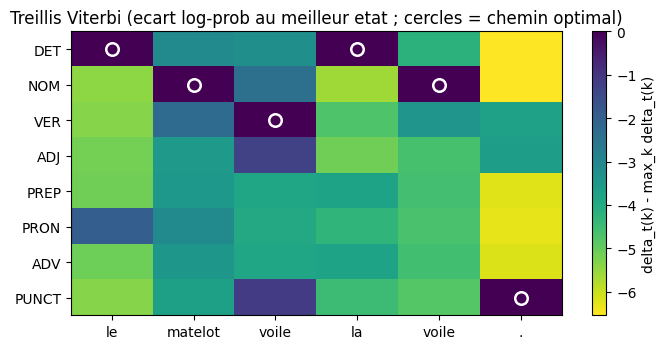

In [8]:
# Treillis complet de la phrase a double lecture : texte puis figure.
s = TEST[8]
ws = mots(s)
chemin, dlt, bp = viterbi(ws)

print(f"Phrase   : {' '.join(ws)}")
print(f"Viterbi  : {' '.join(TAGS[k] for k in chemin)}")
print()
print("Treillis (2 meilleurs etats par position, avec predecesseur gagnant) :")
for t in range(len(ws)):
    ordre = np.argsort(-dlt[t])[:2]
    cell = "  ".join(f"{TAGS[k]:5s} {dlt[t, k]:7.2f} <-{TAGS[bp[t, k]]:5s}" if t > 0 else f"{TAGS[k]:5s} {dlt[t, k]:7.2f}       " for k in ordre)
    print(f"  {ws[t]:9s} {cell}")

fig, ax = plt.subplots(figsize=(7.0, 3.6))
d_norm = (dlt.T - dlt.max(axis=1, keepdims=True).T)  # ecart au meilleur etat par position
im = ax.imshow(d_norm, aspect="auto", cmap="viridis_r")
ax.set_xticks(range(len(ws)), ws)
ax.set_yticks(range(K), TAGS)
ax.plot(range(len(ws)), chemin, "o", ms=9, mfc="none", mec="white", mew=1.8)
ax.set_title("Treillis Viterbi (ecart log-prob au meilleur etat ; cercles = chemin optimal)")
fig.colorbar(im, ax=ax, label="delta_t(k) - max_k delta_t(k)")
plt.tight_layout()
plt.show()

### Lecture — lire le treillis et ses backpointers

Le tableau texte donne, position par position, les deux états dominants et leur **prédécesseur gagnant** : on y lit la competition `NOM` contre `VER` aux positions de *voile*, et le détachement progressif du chemin optimal. La figure rend le même treillis visible : l'échelle est **l'écart au meilleur état de chaque position** (les $\delta$ absolus étant monotonement décroissants par construction), et les cercles blancs tracent le chemin de Viterbi reconstruit par les backpointers. On voit le chemin **coller à la crête** — et les positions ambiguës se reconnaissent à leurs deux crêtes proches.

## 5. Le cas non dégénéré — là où le contexte renverse la décision

Toute la démonstration tient dans deux phrases minimales :

| Phrase | Décideur token seul | Viterbi |
|---|---|---|
| *la porte verte* | `porte` → VER (émission dominante) | `porte` → **NOM** (car `DET → NOM`) |
| *elle porte une robe* | `porte` → VER | `porte` → **VER** (car `PRON → VER`) |

Le **même mot**, deux sorties différentes — pilotées par l'état précédent. Ce n'est pas un cas dégénéré fabriqué pour la cause : les paires minimales sont dans le test, et la mesure ci-dessous énumère **tous** les tokens où l'argmax des émissions seules et le décodage Viterbi divergent, avec le contexte autour, l'étiquette d'or, et le verdict.

In [9]:
def argmax_emissions(words_seq):
    """Decideur token par token : argmax_k P(w | t) a chaque position."""
    return [TAGS[int(np.argmax(logB[:, wi(w)]))] for w in words_seq]

print("Renversements : tokens ou argmax-emissions != Viterbi, sur le TEST")
print(f"{'phrase':34s} {'mot':9s} {'emis':6s} {'viterbi':8s} {'or':6s} verdict")
flips = flips_vers_or = 0
for i, s in enumerate(TEST):
    ws = mots(s)
    emis = argmax_emissions(ws)
    vit = [TAGS[k] for k in viterbi(ws)[0]]
    for j in range(len(ws)):
        if emis[j] != vit[j]:
            flips += 1
            bon = vit[j] == gold(s)[j]
            flips_vers_or += bon
            ctx = " ".join(ws[max(0, j - 1):j + 2])
            print(f"{(' '.join(ws))[:33]:34s} {ws[j]:9s} {emis[j]:6s} {vit[j]:8s} {gold(s)[j]:6s} {'CORRIGE' if bon else 'PERDU'}  [{ctx}]")
print()
print(f"Total : {flips} renversements, dont {flips_vers_or} vers l'etiquette d'or")

Renversements : tokens ou argmax-emissions != Viterbi, sur le TEST
phrase                             mot       emis   viterbi  or     verdict
la voile rouge tourne .            voile     VER    NOM      NOM    CORRIGE  [la voile rouge]
la voile rouge tourne .            tourne    ADV    PUNCT    VER    PERDU  [rouge tourne .]
elle porte une robe bleue .        robe      ADV    NOM      NOM    CORRIGE  [une robe bleue]
il voile la vérité .               vérité    ADV    NOM      NOM    CORRIGE  [la vérité .]
le garde ferme la grille .         garde     VER    NOM      NOM    CORRIGE  [le garde ferme]
le garde ferme la grille .         grille    ADV    NOM      NOM    CORRIGE  [la grille .]
elle coupe le gazon .              gazon     ADV    NOM      NOM    CORRIGE  [le gazon .]
la coupe brille .                  coupe     VER    NOM      NOM    CORRIGE  [la coupe brille]
la coupe brille .                  brille    VER    ADJ      VER    PERDU  [coupe brille .]
il la garde .           

### Lecture — le contexte change réellement la décision, et souvent pour le mieux

La sortie énumère **tous** les renversements — chacun est un token où la **même** information locale (l'émission) existe, mais où la chaîne de transitions impose un autre état. Les inconnus dominent la liste (*robe*, *matelot*, *vérité*…) : l'émission d'un inconnu est quasi uniforme, donc **inutilisable seule** — c'est le contexte (`une _`, `le _`) qui les résout, presque toujours vers l'or (`CORRIGÉ`). Les mots ambigus y figurent aussi : *la voile rouge*, *le garde ferme*, *la coupe brille*, *une avance rapide*, le second *voile* du *matelot*, et *la porte verte* — **six** renversements VER→NOM, tous vers l'or, exactement là où l'émission se trompait. La colonne verdict montre aussi les pertes : le renversement est une **règle de décision globale**, pas une garantie locale — le cas *il la garde* (section 9) y perd. Le bilan net se mesure en section 6.

## 6. La baseline indépendante par token — le plancher à battre

La baseline décide chaque token **indépendamment** de ses voisins : pour un mot vu au train, l'étiquette **majoritaire** de ses occurrences ; pour un inconnu, l'étiquette majoritaire **globale**. C'est le « tag le plus fréquent » des manuels — le même plancher que la baseline token-wise du [03_CRF_Etiquetage_Sequentiel](03_CRF_Etiquetage_Sequentiel.ipynb). Trois systèmes montent sur le banc : la baseline, les émissions seules du HMM (section 5), et le Viterbi complet.

baseline (majorite/mot)    38/53 = 0.717
emissions seules           38/53 = 0.717
viterbi (HMM complet)      47/53 = 0.887


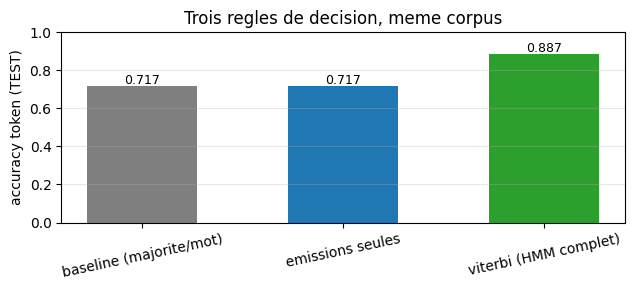

In [10]:
# Baseline : tag majoritaire par mot (inconnus -> tag global majoritaire).
cnt_by_word = {}
for sent in TRAIN:
    for w, t in sent:
        cnt_by_word.setdefault(w, Counter())[t] += 1
word_major = {w: c.most_common(1)[0][0] for w, c in cnt_by_word.items()}
TAG_MAJ_GLOBAL = Counter(t for s in TRAIN for _, t in s).most_common(1)[0][0]

def baseline(words_seq):
    """Etiquette majoritaire du mot dans le train (ou globale si inconnu)."""
    return [word_major.get(w, TAG_MAJ_GLOBAL) for w in words_seq]

def accuracy(fn, data=TEST):
    ok = tot = 0
    for s in data:
        pred = fn(mots(s))
        ok += sum(a == b for a, b in zip(pred, gold(s))); tot += len(gold(s))
    return ok, tot

systemes = {
    "baseline (majorite/mot)": baseline,
    "emissions seules": argmax_emissions,
    "viterbi (HMM complet)": lambda ws: [TAGS[k] for k in viterbi(ws)[0]],
}
res = {}
for nom, fn in systemes.items():
    ok, tot = accuracy(fn)
    res[nom] = ok / tot
    print(f"{nom:26s} {ok}/{tot} = {ok/tot:.3f}")

fig, ax = plt.subplots(figsize=(6.5, 3.0))
noms = list(res)
ax.bar(noms, [res[n] for n in noms], color=["#7f7f7f", "#1f77b4", "#2ca02c"], width=0.55)
for i, n in enumerate(noms):
    ax.text(i, res[n] + 0.012, f"{res[n]:.3f}", ha="center", fontsize=9)
ax.set_ylim(0, 1.0)
ax.set_ylabel("accuracy token (TEST)")
ax.set_title("Trois regles de decision, meme corpus")
ax.grid(alpha=0.3, axis="y")
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

### Lecture — trois niveaux mesurés

La baseline et les émissions seules font **jeu identique** sur ce corpus : l'argmax d'émission ne diffère du tag majoritaire que par le facteur $P(t)$, et les deux familles d'erreurs coïncident ici. Le saut vient du **Viterbi complet** : environ **+17 points** d'accuracy — c'est la valeur ajoutée, mesurée, de l'hypothèse markovienne sur ce corpus. Ce triptyque (plancher indépendant / émissions / séquence) est exactement celui du CRF du notebook 03, qui atteindra le même effet par des poids de transition **appris** plutôt qu'estimés générativement.

## 7. Témoin bibliothèque I — hmmlearn, les mêmes paramètres rechargés

Premier témoin : le paquet `hmmlearn` fournit `CategoricalHMM`, un HMM à émissions catégorielles. Nous l'alimentons avec **nos** paramètres estimés ($\pi$, $A$, $B$ telles quelles) — il n'apprend rien. Ses deux méthodes clés implémentent **indépendamment** nos deux algorithmes : `score` (forward : $\log P(W)$, la somme des chemins) et `predict` (Viterbi : le chemin optimal). La concordance attendue est **exacte** — même modèle, mêmes calculs, autre code : c'est un étalonnage d'implémentation, pas de modélisation.

In [11]:
from hmmlearn.hmm import CategoricalHMM

h = CategoricalHMM(n_components=K, init_params="")   # aucun re-apprentissage
h.startprob_, h.transmat_, h.emissionprob_ = PI, A, B

max_ecart = 0.0
mismatches = 0
for s in TEST:
    ws = mots(s)
    X = np.array([[wi(w)] for w in ws])          # hmmlearn attend (T, 1) indices
    mine_v = viterbi(ws)[0]
    lib_v = list(h.predict(X))
    mismatches += sum(a != b for a, b in zip(mine_v, lib_v))
    max_ecart = max(max_ecart, abs(h.score(X) - forward_log(ws)))

print(f"TEMOIN hmmlearn (memes parametres pi/A/B, algorithmes independants) :")
print(f"  max |score - forward_log|      = {max_ecart:.2e}  (precision machine attendue)")
print(f"  tokens ou predict != viterbi   = {mismatches}")

TEMOIN hmmlearn (memes parametres pi/A/B, algorithmes independants) :
  max |score - forward_log|      = 7.11e-15  (precision machine attendue)
  tokens ou predict != viterbi   = 0


### Lecture — concordance numérique et de chemin avec le témoin

Écart de l'ordre de $10^{-15}$ entre le `score` de hmmlearn et notre forward (limite de la double précision), et **zéro** token de divergence entre `predict` et notre Viterbi : sur les dix phrases du test, les deux implémentations indépendantes rendent des valeurs indiscernables à la précision machine. C'est un **contrôle de cohérence croisé**, pas une démonstration formelle — il n'établit pas l'exactitude des algorithmes sur toute entrée, mais il corrobore fortement la section 3 (la somme forward), la section 4 (le max Viterbi et ses backpointers) et le lissage, puisque la matrice `B` lissée est partie de l'état du témoin. Verdict SOTA : le notebook exécute le vrai outil (`hmmlearn` installé, invoqué, sorties ci-dessus) — **SOTA-OK**, sans substitution.

## Exercice 1 — backward et décodage marginal (MPM)

Viterbi maximise la probabilité du **chemin entier** ; rien ne garantit que chaque position, prise isolément, y soit la plus probable. Le décodage **marginal** (maximum *a posteriori* par position) choisit à chaque position $i$ l'état $\arg\max_k P(t_i = k \mid W)$ — le chemin qui **minimise le nombre d'erreurs attendu par token**, au prix de possibles suites localement improbables.

**Objectif** : implémenter `backward_log` (la récurrence symétrique du forward, $\beta$), puis `decode_mpm` qui combine la table forward $\alpha$ et $\beta$ (backward), normalise, et prend l'argmax par position. Comparer sur le test au chemin de Viterbi : combien de tokens divergent, et dans quel sens ?

- **Étape 0** — écrire `forward_table`, une variante de `forward_log` qui **conserve la table $\alpha$ complète** — `forward_log` ne retourne que le scalaire final $\log P(W)$ — et vérifier que `np.logaddexp.reduce(forward_table(ws)[-1])` redonne `forward_log(ws)` ;
- **Étape 1** — initialiser $\beta_{T-1}(k) = 0$ pour tout $k$ (log de 1) ;
- **Étape 2** — remonter : $\beta_t(k) = \log\sum_j e^{\,\log A_{kj} + \log B_j(w_{t+1}) + \beta_{t+1}(j)}$ ;
- **Étape 3** — $\log P(t_i = k \mid W) = \alpha_i(k) + \beta_i(k) - \log P(W)$, puis `argmax` par position — où $\alpha_i(k)$ est la **somme** forward, et non le max de Viterbi $\delta_i(k)$ : confondre les deux tables fausserait les postérieures, et c'est précisément ce que cet exercice apprend à distinguer.

> **Indice** : `np.logaddexp.reduce` sert exactement comme dans `forward_log` ; et `log P(W)` est déjà la valeur retournée par `forward_log`.

In [12]:
def backward_log(words_seq):
    """beta_t(k) = log P(w_{t+1..T} | t_i = k), en log-espace."""
    # TODO etudiant : Etapes 1-2 decrites ci-dessus.
    print("Exercice a completer")
    return None

def decode_mpm(words_seq):
    """Chemin marginal : argmax_k P(t_i = k | W) a chaque position."""
    # TODO etudiant : Etape 3 (combiner forward et backward, normaliser par log P(W)).
    print("Exercice a completer")
    return None

decode_mpm(mots(TEST[8]))
# Une fois implements :
# for i, s in enumerate(TEST):
#     mpm = decode_mpm(mots(s))
#     vit = [TAGS[k] for k in viterbi(mots(s))[0]]
#     ecart = sum(a != b for a, b in zip(mpm, vit))
#     print(f"test[{i}] MPM vs Viterbi : {ecart} token(s) divergent")

Exercice a completer


## 8. Témoin bibliothèque II — nltk, un pipeline complet sans lissage

Second témoin : `nltk.tag.hmm.HiddenMarkovModelTrainer` entraîne **de bout en bout** un HMM supervisé sur notre train — estimation **et** décodage lui appartiennent. À la différence de notre estimation, celle de NLTK est un MLE **sans lissage** : le moindre mot absent du train rend son émission nulle dans chaque état, et le chemin qui le traverse disparaît. Notre test contient 8 types inconnus (section 1) : la prédiction est mesurable, pas devinée. Note d'exécution : NLTK convertit ses log-probabilités nulles ($-\infty$) en cast `float32` interne, ce qui déclenche des `RuntimeWarning: overflow encountered in cast` — bénins pour le chemin retourné, capturés ci-dessous pour la lisibilité.

In [13]:
import warnings
from nltk.tag import hmm as nltk_hmm

train_nltk = [list(s) for s in TRAIN]
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)   # cast float32 des -inf internes a NLTK, bénin
    tagger = nltk_hmm.HiddenMarkovModelTrainer().train_supervised(train_nltk)
    preds_nltk = [[t for _, t in tagger.tag(mots(s))] for s in TEST]

ok_nltk = sum(a == b for s, p in zip(TEST, preds_nltk) for a, b in zip(p, gold(s)))
tot_test = sum(len(gold(s)) for s in TEST)
accord = sum(a == TAGS[b] for s, p in zip(TEST, preds_nltk)
             for a, b in zip(p, viterbi(mots(s))[0]))

print(f"TEMOIN nltk (train_supervised, MLE sans lissage, Viterbi interne) :")
print(f"  accuracy nltk sur le TEST      : {ok_nltk}/{tot_test} = {ok_nltk/tot_test:.3f}")
print(f"  accord token avec notre Viterbi : {accord}/{tot_test}")

# Controle causal : que devient NOTRE pipeline en MLE pur (alpha = 0, sans <UNK>) ?
# Une phrase contenant un mot hors du vocabulaire du train y a une emission nulle
# dans les 8 etats -> vraisemblance strictement nulle, chemin indeterminable.
phrases_avec_inconnu = [i for i, s in enumerate(TEST) if any(w not in train_words for w, _ in s)]
print()
print("Controle MLE pur (alpha=0, sans <UNK>) : phrases du TEST avec au moins un inconnu :")
for i in phrases_avec_inconnu:
    inconnus = [w for w, _ in TEST[i] if w not in train_words]
    print(f"  test[{i}] {' '.join(mots(TEST[i])):34s} inconnu(s) : {', '.join(inconnus)}")
print(f"=> {len(phrases_avec_inconnu)}/10 phrases de vraisemblance nulle en MLE pur ;"
      f" seules les {10 - len(phrases_avec_inconnu)} phrases restantes restent decodables.")


TEMOIN nltk (train_supervised, MLE sans lissage, Viterbi interne) :
  accuracy nltk sur le TEST      : 26/53 = 0.491
  accord token avec notre Viterbi : 23/53

Controle MLE pur (alpha=0, sans <UNK>) : phrases du TEST avec au moins un inconnu :
  test[0] la voile rouge tourne .            inconnu(s) : tourne
  test[1] elle porte une robe bleue .        inconnu(s) : robe
  test[2] il voile la vérité .               inconnu(s) : vérité
  test[3] le garde ferme la grille .         inconnu(s) : grille
  test[4] elle coupe le gazon .              inconnu(s) : gazon
  test[7] une avance rapide surprend .       inconnu(s) : rapide
  test[8] le matelot voile la voile .        inconnu(s) : matelot
  test[9] le concierge ouvre la porte verte . inconnu(s) : concierge
=> 8/10 phrases de vraisemblance nulle en MLE pur ; seules les 2 phrases restantes restent decodables.


### Lecture — l'effondrement du non-lissage, et ses limites d'interprétation

Là où notre HMM lissé décode proprement, le pipeline NLTK **sans lissage** s'effondre : accuracy moitié moindre, accord partiel avec nos chemins. Le contrôle ci-dessus ancre le mécanisme sur **notre propre pipeline** : huit des dix phrases du test contiennent un type inconnu, et en MLE pur chacune a une vraisemblance strictement nulle — c'est le $\log 0$ de la section 2 à l'œuvre.

Nuance d'honnêteté : ce contraste est **illustratif**, pas une isolation causale stricte. Le score exact de NLTK dépend aussi de sa convention de repli sur les chemins de vraisemblance nulle (des suites guidées par les seuls tokens connus, différentes des nôtres) ; ce que le contraste isole, c'est la **cause dominante commune** — l'absence de lissage. Ce témoin n'est pas un contre-exemple pour NLTK : son API documente ce choix et fournit des estimateurs lissables ; c'est le même contraste que le MLE nu contre Laplace dans le [02_NGrammes_Modeles_De_Langue](02_NGrammes_Modeles_De_Langue.ipynb).

## Exercice 2 — le poids du lissage : balayage de α

Le add-1 de la section 2 est un choix, pas une nécessité. Que gagne-t-on ou perd-on à l'adoucir (α = 0.01) ou à le durcir (α = 5) ?

**Objectif** : faire varier α **des émissions uniquement**, ré-estimer $B$, redécoder le test par Viterbi, et rapporter l'accuracy token pour chaque α.

- **Étape 1** — factoriser l'estimation : `estimer_hmm` accepte déjà `alpha_e` ; reconstruire `logB` (et seulement elle) pour chaque α ;
- **Étape 2** — pour chaque α, décoder les 10 phrases du test et compter les tokens corrects ;
- **Étape 3** — afficher la courbe `accuracy(α)` et localiser l'optimum par rapport au α = 1 de ce notebook.

> **Indice** : les transitions et π restent celles du train (α_t inchangé) ; seules les émissions bougent — et avec elles le sort des 8 inconnus du test.

In [14]:
def balayage_alpha(alphas=(0.01, 0.1, 0.5, 1.0, 5.0)):
    """Re-estimer B avec lissage add-alpha, decoder le TEST, retourner {alpha: accuracy}."""
    # TODO etudiant : Etapes 1-3 decrites ci-dessus.
    print("Exercice a completer")
    return None

balayage_alpha()
# Une fois implemente :
# res = balayage_alpha()
# for a, acc in res.items():
#     print(f"alpha = {a:5.2f} -> accuracy = {acc:.3f}")

Exercice a completer


## 9. Analyse d'erreurs — six tokens résistent

Aucune métrique ne vaut la lecture des erreurs une à une — la discipline du [03_CRF_Etiquetage_Sequentiel](03_CRF_Etiquetage_Sequentiel.ipynb), appliquée à notre Viterbi.

In [15]:
print("Erreurs du Viterbi sur le TEST (token, contexte, predit contre or) :")
n_err = 0
for i, s in enumerate(TEST):
    ws = mots(s)
    vit = [TAGS[k] for k in viterbi(ws)[0]]
    for j in range(len(ws)):
        if vit[j] != gold(s)[j]:
            n_err += 1
            ctx = " ".join(ws[max(0, j - 2):j + 3])
            print(f"  test[{i}] {ws[j]:10s} predit={vit[j]:6s} or={gold(s)[j]:6s}  [{ctx}]")
print(f"\nTotal : {n_err} tokens en erreur sur {sum(len(gold(s)) for s in TEST)}")

Erreurs du Viterbi sur le TEST (token, contexte, predit contre or) :
  test[0] tourne     predit=PUNCT  or=VER     [voile rouge tourne .]
  test[5] brille     predit=ADJ    or=VER     [la coupe brille .]
  test[6] la         predit=DET    or=PRON    [il la garde .]
  test[6] garde      predit=NOM    or=VER     [il la garde .]
  test[7] rapide     predit=VER    or=ADJ     [une avance rapide surprend .]
  test[7] surprend   predit=ADV    or=VER     [avance rapide surprend .]

Total : 6 tokens en erreur sur 53


### Lecture — trois familles d'erreurs, une leçon

Les erreurs se groupent en familles (sortie ci-dessus) : le **clitique objet** (*il la garde* : notre chaîne préfère `PRON DET` à `PRON PRON`, car le train n'offre que quatre clitiques contre des dizaines de `la` déterminants) ; l'**inconnu verbal** (*tourne* : l'émission d'inconnu pointe vers l'état rare `ADV`, piège documenté en section 2, et la transition qui suit ne suffit pas toujours à le rattraper) ; et l'**alternance ADJ/VER en fin de syntagme** (*coupe brille* : après un nom, `NOM ADJ .` et `NOM VER .` sont tous deux plausibles dans ce petit train). Trois remèdes, du plus simple au plus structurel : plus de clitiques au train (exercice 3), un lissage asymétrique pour les inconnus (exercice 2), ou des poids de transition **conditionnés aux mots** — exactement ce qu'un CRF apprend (notebook 03).

## Exercice 3 — étendre le corpus : le mot « couche »

La famille d'erreurs *clitique/ambigu* se répare par les **données** : ajouter des phrases d'entraînement bien choisies déplace les comptages MLE — c'est l'avantage d'un modèle génératif estimé par comptage.

**Objectif** : étendre le corpus avec le mot ambigu *couche* — nom (*une couche épaisse*) et verbe (*la nourrice couche les enfants*) — puis ré-estimer et mesurer ce qui change **et ce qui ne change pas**.

- **Étape 1** — écrire 4 à 6 phrases couvrant les deux sens, dans le style des blocs du corpus (section 1) ;
- **Étape 2** — les ajouter au **train** (jamais au test), ré-estimer $\pi, A, B$ par `estimer_hmm` ;
- **Étape 3** — décoder une phrase-test contenant *couche* en contexte minoritaire, et rapporter : le chemin obtenu, la réponse de l'argmax d'émissions, et l'effet sur l'accuracy du test d'origine.

> **Indice** : les paramètres de l'HMM ne « savent » rien du mot *couche* avant vos phrases — chaque sens doit apparaître au moins deux fois pour lutter contre le contexte.

In [16]:
def etendre_avec_couche():
    """Ajouter des phrases 'couche' (NOM et VER) au train, re-estimer, re-decoder."""
    # TODO etudiant : Etapes 1-3 decrites ci-dessus.
    print("Exercice a completer")
    return None

etendre_avec_couche()

Exercice a completer


## Conclusion : la séquence comme preuve, la mesure comme juge

**Ce que ce notebook a construit** — et que la série ne portait pas avant lui :

1. **Un HMM d'étiquetage morphosyntaxique complet from scratch** : estimation MLE des transitions et émissions sur un corpus annoté, lissage add-1 avec symbole d'inconnu, forward en log-espace (`np.logaddexp`), décodage Viterbi avec backpointers et reconstruction à l'envers — le tout CPU, déterministe, sans dépendance au-delà de NumPy ;
2. **Un corpus POS français synthétique à provenance explicite** — rédigé pour ce notebook, pas un benchmark — concentrant deux couches d'ambiguïté mesurables : cinq mots NOM/VER et trois clitiques DET/PRON, jusqu'à la phrase à double lecture *le matelot voile la voile*, décodée correctement ;
3. **La démonstration non dégénérée du contexte de séquence** : les renversements token par token entre l'argmax d'émissions et le Viterbi complet sont énumérés avec leur contexte et leur verdict — la même forme *porte* est étiquetée deux fois différemment selon la chaîne ;
4. **Trois niveaux mesurés sur le même banc** : baseline majoritaire par mot, émissions seules, Viterbi complet — l'hypothèse markovienne vaut ici une quinzaine de points d'accuracy ;
5. **Deux témoins bibliothèque réellement exécutés** : `hmmlearn` chargé avec nos paramètres reproduit forward (`score`) et Viterbi (`predict`) **à l'identique** (écart machine, zéro divergence) ; `nltk` entraîné sans lissage s'effondre sur les inconnus — la mesure de ce que le add-1 achète ;
6. **Une analyse d'erreurs lue une à une** : clitiques objets, inconnus verbaux, alternance ADJ/VER — trois familles dont deux se réparent par les données (exercices 2 et 3) et dont la troisième appelle les poids conditionnels du CRF.

**Étape suivante** : le [03_CRF_Etiquetage_Sequentiel](03_CRF_Etiquetage_Sequentiel.ipynb) garde le treillis et le Viterbi, mais **réécrit la paramétrisation** — scores d'émission et de transition appris discriminativement, conditionnellement aux mots et à leurs traits, par maximisation de la vraisemblance conditionnelle. Le génératif et le discriminatif, même banc d'expérience.